In this task, I will be implementing a linear regression model for detecting diabetes risk

In [1]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
print(datasets.load_diabetes(as_frame=True).DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [3]:
x, y = datasets.load_diabetes(return_X_y=True, as_frame=True)
feature_names = list(x.columns)
x.head(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504


In [4]:
x, y = datasets.load_diabetes(return_X_y=True)
x

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]])

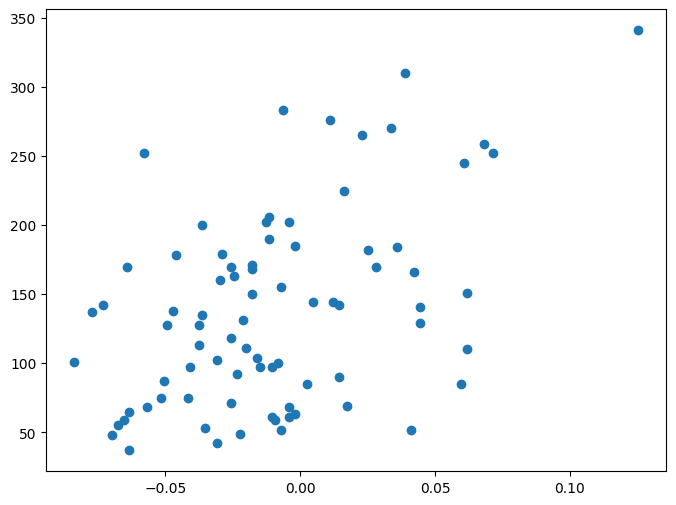

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(x[:80, 2], y[:80])
plt.show()

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
n_train = x_train.shape[0]
n_test = x_test.shape[0]

# the purpose of normalizing is to standardizing it
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

# We add the bias term here. So the bias is basically the y-intercept
# bias is optional
bias_train = np.ones([n_train, 1])
bias_test = np.ones([n_test, 1])
x_train_b = np.concatenate([x_train_s, bias_train], axis=1)
x_test_b = np.concatenate([x_test_s, bias_test], axis=1)

# if after adding the bias term, and then normalizing it, then the y-intercept would be 0

In [7]:

# basically the dot product of x and theta
# x.shape: n_examples, n_features
# theta.shape: n_feature
def f(x, theta):
    return np.einsum('ij,j->i', x, theta)

# mean squared error function
# you need to get the difference
# x.shape: n_examples, n_features
# y.shape: n_feature
def mse(x, y, theta):
    diff = f(x, theta) - y
    return np.mean((f(x, theta) - y) ** 2) # this will just return 1 number

# the gradient
# x.shape: n_examples, n_features
# theta.shape: n_feature
# y.shape: n_example
# output.shape: n_feature
def grad(x, y, theta):
    diff = f(x, theta) - y
    return np.einsum('i,ij->j', diff, x) / x.shape[0] # all examples not just 1

In [8]:
lr = 0.1
n_iters = 5000
theta = np.zeros(x_train_b.shape[1])

for iter in range(n_iters):
    theta -= lr * grad(x_train_b, y_train, theta) # we use the x_train with the bias
    if iter % 1000 == 0 or iter == n_iters - 1: # every 1000 steps, we print out the loss
        train_mse = mse(x_train_b, y_train, theta)
        print(f"  Iter {iter:4d} | Train MSE: {train_mse:.2f}")

  Iter    0 | Train MSE: 23765.11
  Iter 1000 | Train MSE: 2873.50
  Iter 2000 | Train MSE: 2869.33
  Iter 3000 | Train MSE: 2868.67
  Iter 4000 | Train MSE: 2868.57
  Iter 4999 | Train MSE: 2868.55


In [9]:
print(f"  Train MSE: {mse(x_train_b, y_train, theta):.2f}")
print(f"  Test  MSE: {mse(x_test_b, y_test, theta):.2f}")

  Train MSE: 2868.55
  Test  MSE: 2899.86


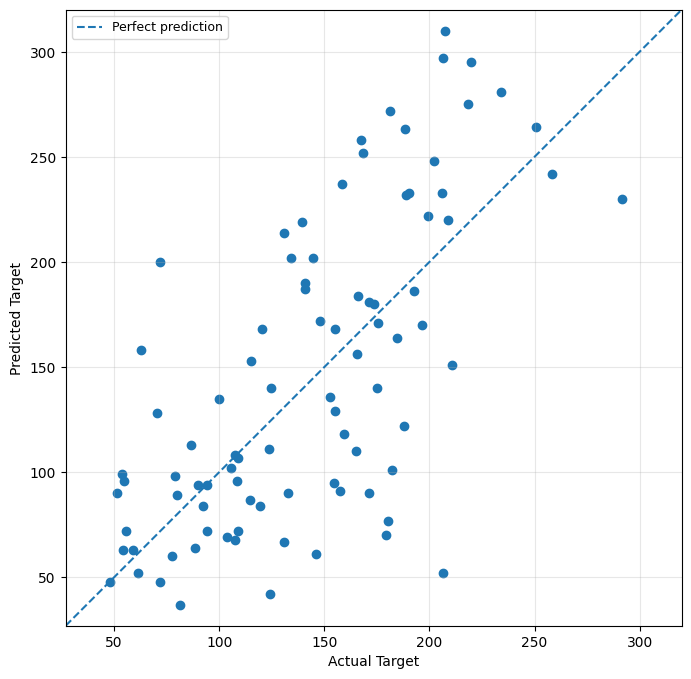

In [10]:
def actual_vs_predicted(y_true, y_pred):
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(y_true, y_pred)
    lims = [min(y_true.min(), y_pred.min()) - 10,
            max(y_true.max(), y_pred.max()) + 10]
    ax.plot(lims, lims, '--', label='Perfect prediction')
    ax.set_xlabel('Actual Target')
    ax.set_ylabel('Predicted Target')
    ax.legend(fontsize=9)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    # return fig

y_train_pred = f(x_train_b, theta)
y_test_pred = f(x_test_b, theta)
actual_vs_predicted(y_test_pred, y_test)

In [11]:
feature_name_weight = {name: weight.item() for name, weight in zip (feature_names, theta)}
feature_name_weight = sorted(feature_name_weight.items(), key=lambda x: -abs(x[1]))
print(feature_name_weight)

[('s1', -44.03862849290952), ('s5', 35.00377242975588), ('bmi', 25.61501676450813), ('s2', 24.320064653690256), ('bp', 16.82633082407299), ('s4', 13.082443516114802), ('sex', -11.510948418967908), ('s3', 7.496001284004293), ('s6', 2.3543341659234525), ('age', 1.7559923763051295)]


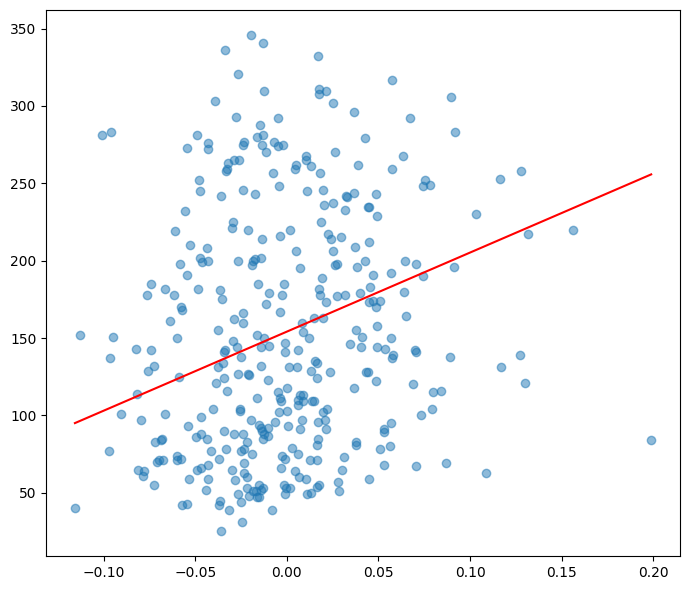

In [12]:
feature_name = 's2'
feature_idx = feature_names.index(feature_name)
feature_weight = theta[feature_idx]
x_feat = x_train[:, feature_idx]

w_bias = theta[-1]
w_feat = feature_weight
feat_mean = scaler.mean_[feature_idx]
feat_std = scaler.scale_[feature_idx]

# Regression line:  y = w_bias + w_feat * (x - mean) / std
x_line = np.linspace(x_feat.min(), x_feat.max(), 200) # regression line
y_line = w_bias + w_feat * (x_line - feat_mean) / feat_std

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(x_feat, y_train, alpha=0.5)
ax.plot(x_line, y_line, color='red')
fig.tight_layout()